# PatchCore Experiment Notebook

In [1]:
import importlib

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from config import config2
from models.backbone import get_backbone
from datasets.data import MyData
from models.patchcore import PatchCore
from utils.metrics import get_image_auc #get_pixel_auc

print("class:", config2.CLASS_NAME)
print("k:", config2.K)
print("train limit:", config2.TRAIN_LIMIT)
print("test limit:", config2.TEST_LIMIT)
print("test limit per class:", config2.TEST_LIMIT_PER_CLASS)

class: zipper
k: 50
train limit: 50
test limit: 30
test limit per class: 3


## SET Device

In [2]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(device)

mps


## Load Dataset

- datasets/data.py

In [3]:
train_data = MyData(
    config2.CLASS_NAME,
    phase="train",
    batch_size=config2.BATCH_SIZE,
    shuffle=False,
    limit=config2.TRAIN_LIMIT,
)

test_data = MyData(
    config2.CLASS_NAME,
    phase="test",
    batch_size=config2.BATCH_SIZE,
    shuffle=False,
    limit=config2.TEST_LIMIT,
    limit_per_class=config2.TEST_LIMIT_PER_CLASS,
)

print("train images:", len(train_data))
print("test images:", len(test_data))
print("test classes:", test_data.get_classes())

class_counts = {name: 0 for name in test_data.get_classes()}
for _, label in test_data:
    class_counts[test_data.get_classes()[label]] += 1
print("test class counts:", class_counts)
test_data[0]

train images: 50
test images: 24
test classes: ['broken_teeth', 'combined', 'fabric_border', 'fabric_interior', 'good', 'rough', 'split_teeth', 'squeezed_teeth']
test class counts: {'broken_teeth': 3, 'combined': 3, 'fabric_border': 3, 'fabric_interior': 3, 'good': 3, 'rough': 3, 'split_teeth': 3, 'squeezed_teeth': 3}


(tensor([[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],
 
         [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          ...,
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],
 
         [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ...,

## Fit PatchCore

In [4]:
backbone = get_backbone()
patchcore = PatchCore(backbone, k=config2.K, device=device)

patchcore.fit(train_data)

print("memory bank shape:", tuple(patchcore.memory_bank.shape))

memory bank shape: (50, 384)


## Visualize One Result

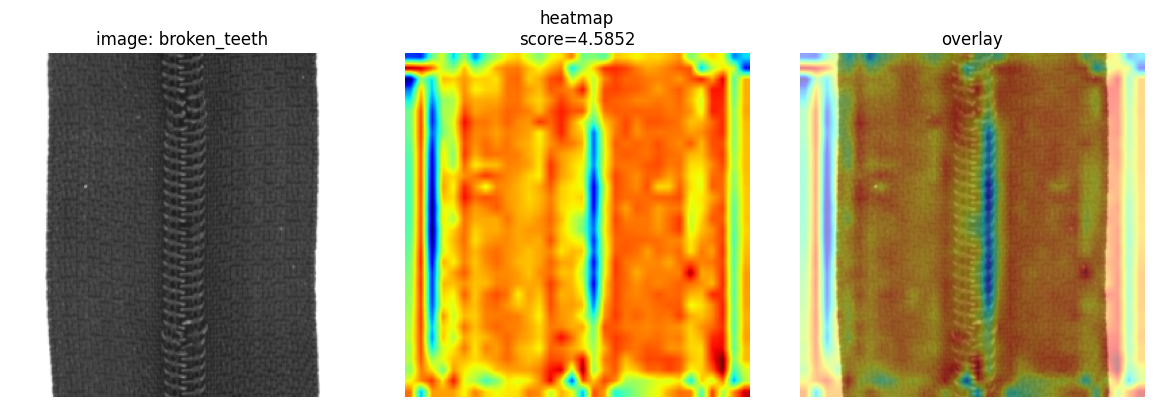

(4.585192680358887, 'broken_teeth')

In [5]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(img):
    img = img.detach().cpu() * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1)


def show_result(index=0):
    img, label = test_data[index]
    score, heatmap = patchcore.predict(img)

    image = denormalize(img).permute(1, 2, 0).numpy()
    heatmap = heatmap.detach().cpu()
    heatmap = F.interpolate(
        heatmap.unsqueeze(0).unsqueeze(0),
        size=image.shape[:2],
        mode="bilinear",
        align_corners=False,
    ).squeeze()
    heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
    heatmap_np = heatmap.numpy()
    label_name = test_data.get_classes()[label]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image)
    axes[0].set_title(f"image: {label_name}")
    axes[0].axis("off")

    axes[1].imshow(heatmap_np, cmap="jet")
    axes[1].set_title(f"heatmap\nscore={score.item():.4f}")
    axes[1].axis("off")

    axes[2].imshow(image)
    axes[2].imshow(heatmap_np, cmap="jet", alpha=0.45)
    axes[2].set_title("overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return score.item(), label_name


show_result(config2.TEST_INDEX)

## Compare Test Scores

In [6]:
scores = []

for i in range(len(test_data)):
    img, label = test_data[i]
    score, _ = patchcore.predict(img)
    scores.append((i, score.item(), test_data.get_classes()[label]))

scores = sorted(scores, key=lambda x: x[1], reverse=True)
scores[:10]

[(7, 7.431535720825195, 'fabric_border'),
 (6, 6.2838335037231445, 'fabric_border'),
 (8, 5.362217426300049, 'fabric_border'),
 (16, 5.267730712890625, 'rough'),
 (19, 5.189715385437012, 'split_teeth'),
 (3, 5.13867712020874, 'combined'),
 (23, 4.876685619354248, 'squeezed_teeth'),
 (1, 4.782017230987549, 'broken_teeth'),
 (5, 4.755124568939209, 'combined'),
 (15, 4.67565393447876, 'rough')]

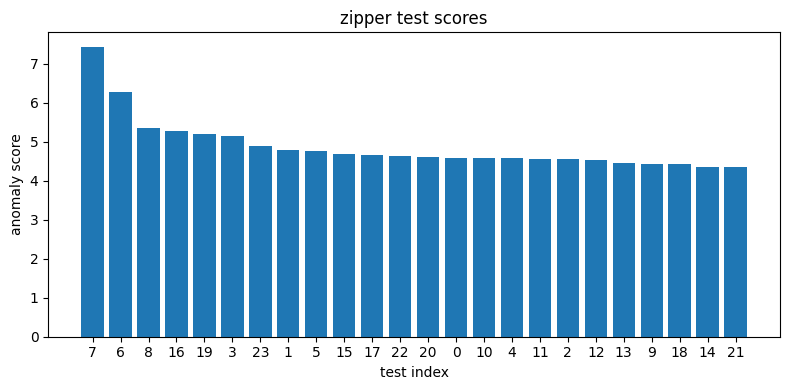

In [7]:
plt.figure(figsize=(8, 4))
plt.bar([str(i) for i, _, _ in scores], [score for _, score, _ in scores])
plt.xlabel("test index")
plt.ylabel("anomaly score")
plt.title(f"{config2.CLASS_NAME} test scores")
plt.tight_layout()
plt.show()

## Inspect Top Scored Images

index: 7 score: 7.4315 label: fabric_border


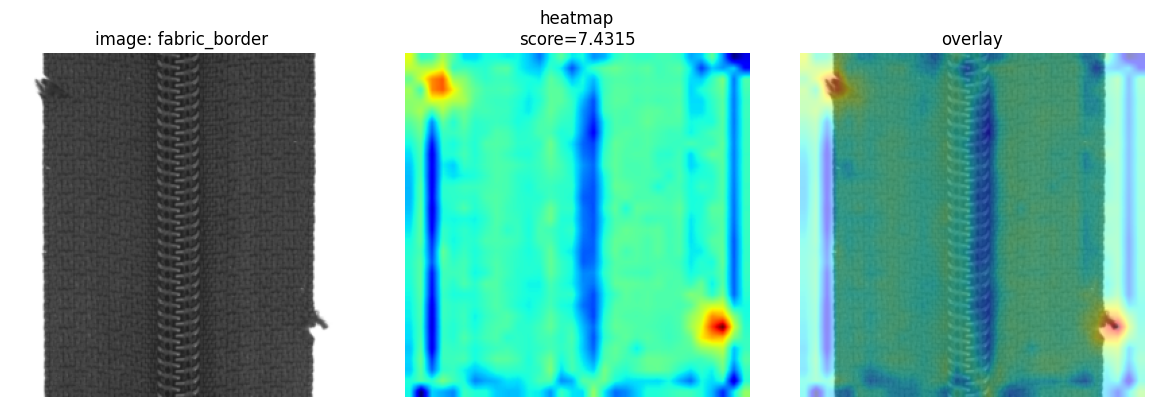

index: 6 score: 6.2838 label: fabric_border


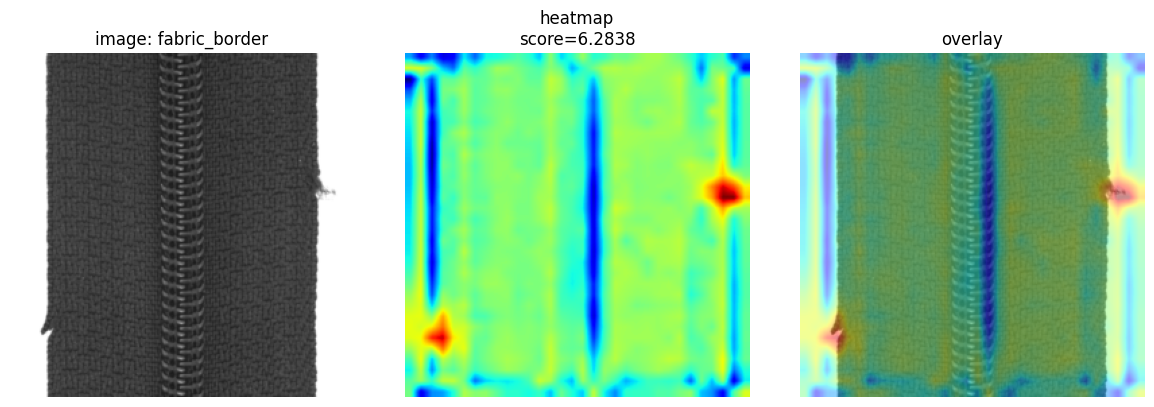

index: 8 score: 5.3622 label: fabric_border


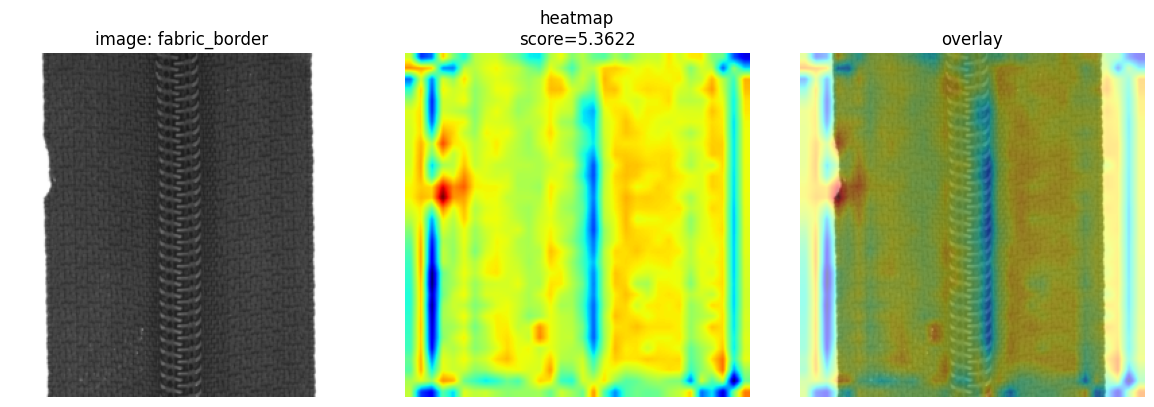

In [8]:
for index, score, label_name in scores[:3]:
    print("index:", index, "score:", round(score, 4), "label:", label_name)
    show_result(index)

In [9]:
image_auc = get_image_auc(test_data, patchcore)
image_auc

np.float64(0.8888888888888888)

In [10]:
# import csv
# import os

# file_path = "results.csv"
# file_exists = os.path.isfile(file_path)

# with open(file_path, 'a', newline="") as f:
#     writer = csv.writer(f)

#     if not file_exists:
#         writer.writerow(["category","train_limit","k","auc"])
#     writer.writerow([config.CLASS_NAME, config.TRAIN_LIMIT, config.K, image_auc ])
        

- pixel단위 auc는 ground_truth 사용 필요. dataloader 추후 수정

In [11]:
# pixel_auc = get_pixel_auc(test_data, patchcore)
# pixel_auc

In [12]:
# import pandas as pd

# data = pd.read_csv("results.csv")
# data

In [13]:
# import pandas as pd
# df = pd.read_csv("results.csv")
# df = df.sort_values(by='auc',ascending = False).reset_index(drop=True)
# df.to_csv("results.csv")

In [14]:
# import pandas as pd
# pd.read_csv("results.csv")